# 02: Time-Domain Dynamics, Waveform Geometry & Energy Forensics

## 1. Research Scope & Objectives
This notebook analyzes the continuous time-domain characteristics of authentic vs synthetic speech signals, focusing on waveform geometry, peak clipping, frame-level energy envelopes, dynamic range, Zero-Crossing Rate (ZCR), and Voice Activity Detection (VAD) boundaries.

### Mathematical Formulations
Frame-level RMS Energy:
$$\text{RMS}[k] = \sqrt{\frac{1}{W}\sum_{n=0}^{W-1} x^2[k \cdot H + n]}$$
Dynamic Range:
$$\text{DR}_{\text{dB}} = 20 \log_{10}\left(\frac{\max(|x[n]|) + \epsilon}{\text{RMS}_{\text{floor}} + \epsilon}\right)$$
Zero-Crossing Rate:
$$\text{ZCR}[k] = \frac{1}{2W}\sum_{n=1}^{W-1} |\text{sgn}(x[k \cdot H + n]) - \text{sgn}(x[k \cdot H + n - 1])|$$

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import soundfile as sf, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, librosa
from src.utils.config import path_config

sns.set_theme(style="whitegrid")
manifest_path = os.path.join(path_config.data_processed, "protocol_manifest.parquet")
df = pd.read_parquet(manifest_path)

## 2. Time-Domain Waveform Geometry Comparison
We compare continuous time-series waveforms for authentic human speech against various synthetic vocoder attacks.

In [2]:
sample_bonafide = df[df.key == "bonafide"].iloc[0]["file_path"]
sample_spoof_a01 = df[(df.key == "spoof") & (df.attack_id == "A01")].iloc[0]["file_path"]
sample_spoof_a04 = df[(df.key == "spoof") & (df.attack_id == "A04")].iloc[0]["file_path"]

y_bon, sr_bon = sf.read(sample_bonafide)
y_a01, sr_a01 = sf.read(sample_spoof_a01)
y_a04, sr_a04 = sf.read(sample_spoof_a04)

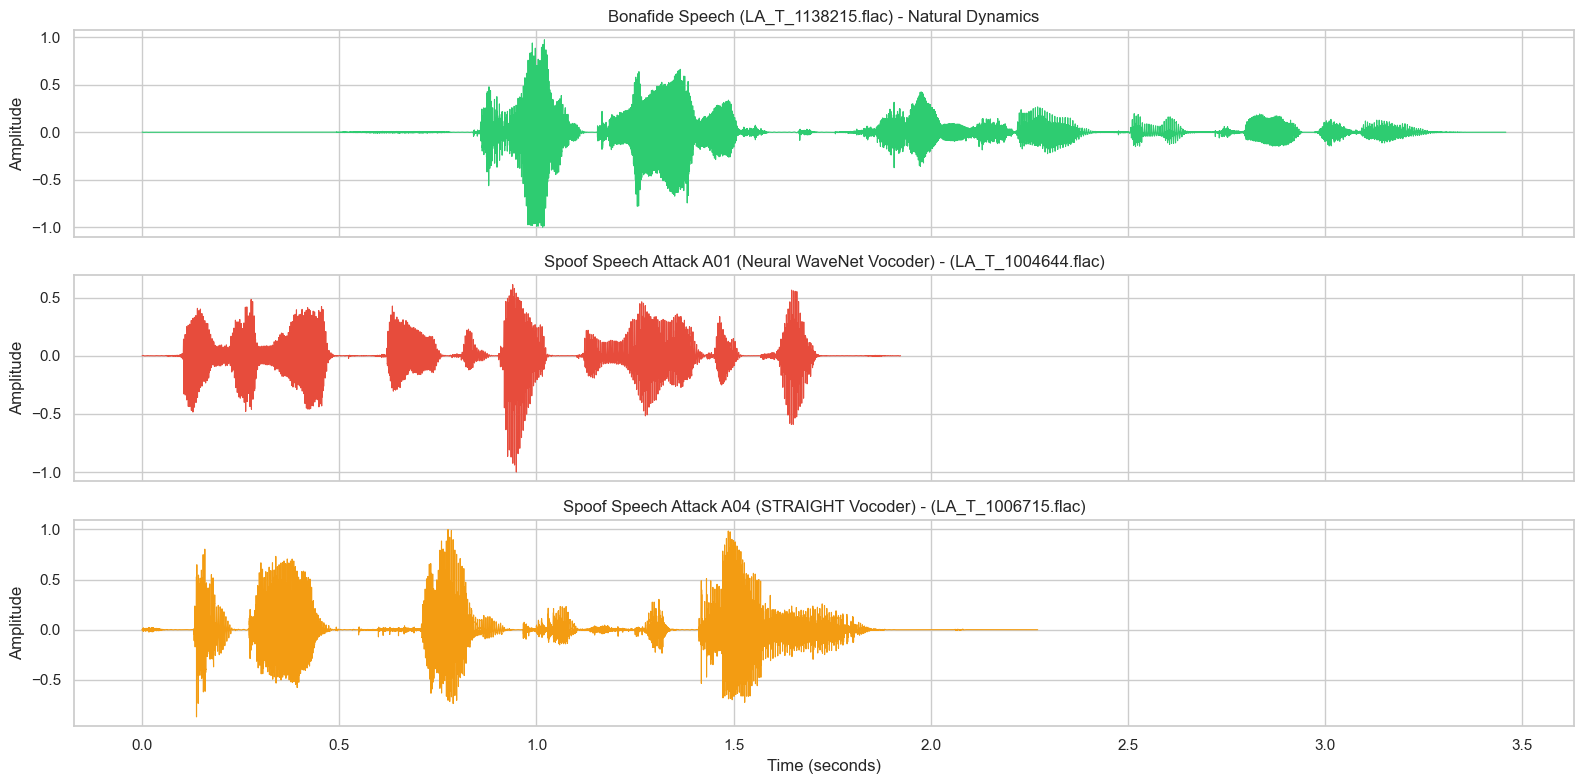

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)
t_bon = np.linspace(0, len(y_bon)/sr_bon, len(y_bon))
t_a01 = np.linspace(0, len(y_a01)/sr_a01, len(y_a01))
t_a04 = np.linspace(0, len(y_a04)/sr_a04, len(y_a04))

axes[0].plot(t_bon, y_bon, color="#2ecc71", lw=0.8)
axes[0].set_title(f"Bonafide Speech ({os.path.basename(sample_bonafide)}) - Natural Dynamics")
axes[0].set_ylabel("Amplitude")

axes[1].plot(t_a01, y_a01, color="#e74c3c", lw=0.8)
axes[1].set_title(f"Spoof Speech Attack A01 (Neural WaveNet Vocoder) - ({os.path.basename(sample_spoof_a01)})")
axes[1].set_ylabel("Amplitude")

axes[2].plot(t_a04, y_a04, color="#f39c12", lw=0.8)
axes[2].set_title(f"Spoof Speech Attack A04 (STRAIGHT Vocoder) - ({os.path.basename(sample_spoof_a04)})")
axes[2].set_ylabel("Amplitude")
axes[2].set_xlabel("Time (seconds)")
plt.tight_layout()
plt.show()

## 3. Duration Distribution & Physical Sampling Characteristics

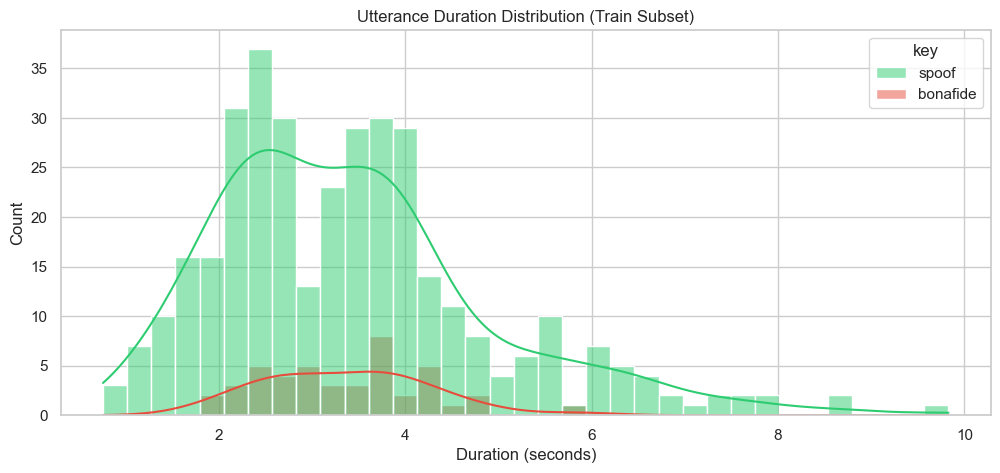

In [4]:
sample_subset = df[df.split == "train"].sample(n=400, random_state=42)
durations = [sf.info(p).duration for p in sample_subset["file_path"]]
sample_subset["duration"] = durations

plt.figure(figsize=(12, 5))
sns.histplot(data=sample_subset, x="duration", hue="key", bins=35, kde=True, palette=["#2ecc71", "#e74c3c"])
plt.title("Utterance Duration Distribution (Train Subset)")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.show()

## 4. Root Mean Square (RMS) Energy & Dynamic Range Forensics
Synthesized speech often exhibits compressed dynamic ranges and unnatural frame-level energy standard deviations.

In [5]:
def extract_energy_metrics(file_paths):
    records = []
    for p in file_paths:
        y, sr = sf.read(p)
        rms = librosa.feature.rms(y=y, frame_length=512, hop_length=256)[0]
        peak = np.max(np.abs(y))
        rms_mean = np.mean(rms)
        rms_std = np.std(rms)
        papr = peak / (rms_mean + 1e-7)
        dr_db = 20 * np.log10((peak + 1e-7) / (np.min(rms) + 1e-7))
        records.append({
            "rms_mean": rms_mean,
            "rms_std": rms_std,
            "papr": papr,
            "dynamic_range_db": dr_db
        })
    return pd.DataFrame(records)

bon_paths = df[(df.split == "train") & (df.key == "bonafide")]["file_path"].head(100)
spf_paths = df[(df.split == "train") & (df.key == "spoof")]["file_path"].head(100)

bon_energy = extract_energy_metrics(bon_paths)
bon_energy["key"] = "bonafide"
spf_energy = extract_energy_metrics(spf_paths)
spf_energy["key"] = "spoof"
energy_df = pd.concat([bon_energy, spf_energy], ignore_index=True)

c:\Users\tamimystic\.conda\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


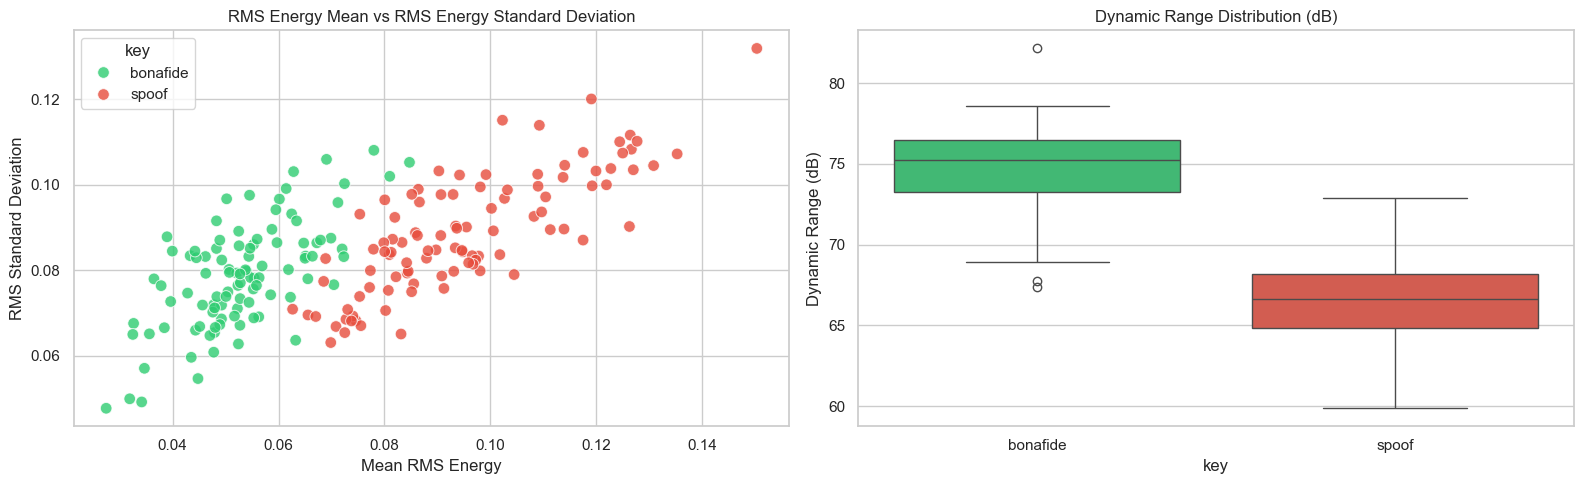

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.scatterplot(data=energy_df, x="rms_mean", y="rms_std", hue="key", palette=["#2ecc71", "#e74c3c"], s=70, alpha=0.8, ax=axes[0])
axes[0].set_title("RMS Energy Mean vs RMS Energy Standard Deviation")
axes[0].set_xlabel("Mean RMS Energy")
axes[0].set_ylabel("RMS Standard Deviation")

sns.boxplot(data=energy_df, x="key", hue='key', legend=False, y="dynamic_range_db", palette=["#2ecc71", "#e74c3c"], ax=axes[1])
axes[1].set_title("Dynamic Range Distribution (dB)")
axes[1].set_ylabel("Dynamic Range (dB)")
plt.tight_layout()
plt.show()

## 5. Zero-Crossing Rate (ZCR) Dynamics & High-Frequency Noise

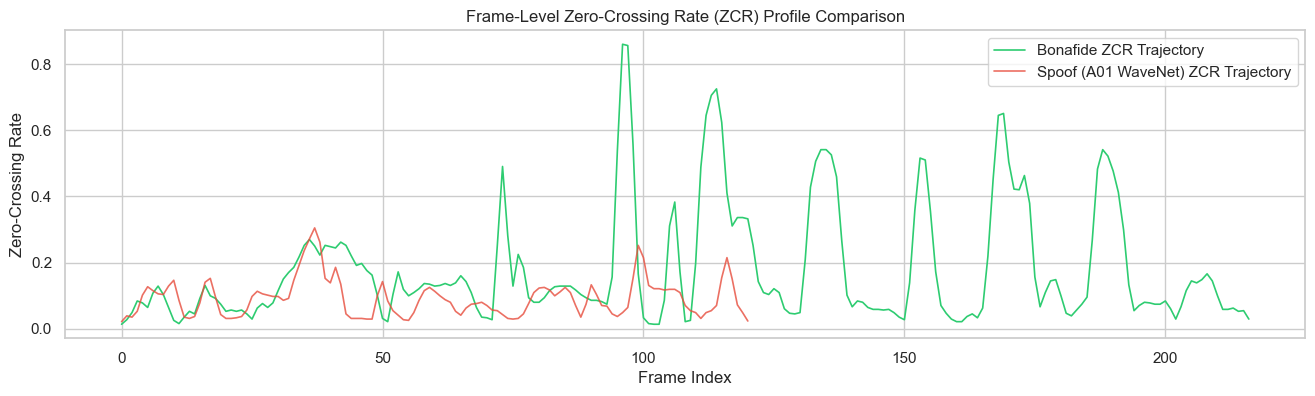

In [7]:
zcr_bon = librosa.feature.zero_crossing_rate(y=y_bon, frame_length=512, hop_length=256)[0]
zcr_a01 = librosa.feature.zero_crossing_rate(y=y_a01, frame_length=512, hop_length=256)[0]

plt.figure(figsize=(16, 4))
plt.plot(zcr_bon, label="Bonafide ZCR Trajectory", color="#2ecc71", lw=1.2)
plt.plot(zcr_a01, label="Spoof (A01 WaveNet) ZCR Trajectory", color="#e74c3c", lw=1.2, alpha=0.8)
plt.title("Frame-Level Zero-Crossing Rate (ZCR) Profile Comparison")
plt.xlabel("Frame Index")
plt.ylabel("Zero-Crossing Rate")
plt.legend()
plt.show()

## 6. Voice Activity Detection (VAD) & Silence Floor Forensics

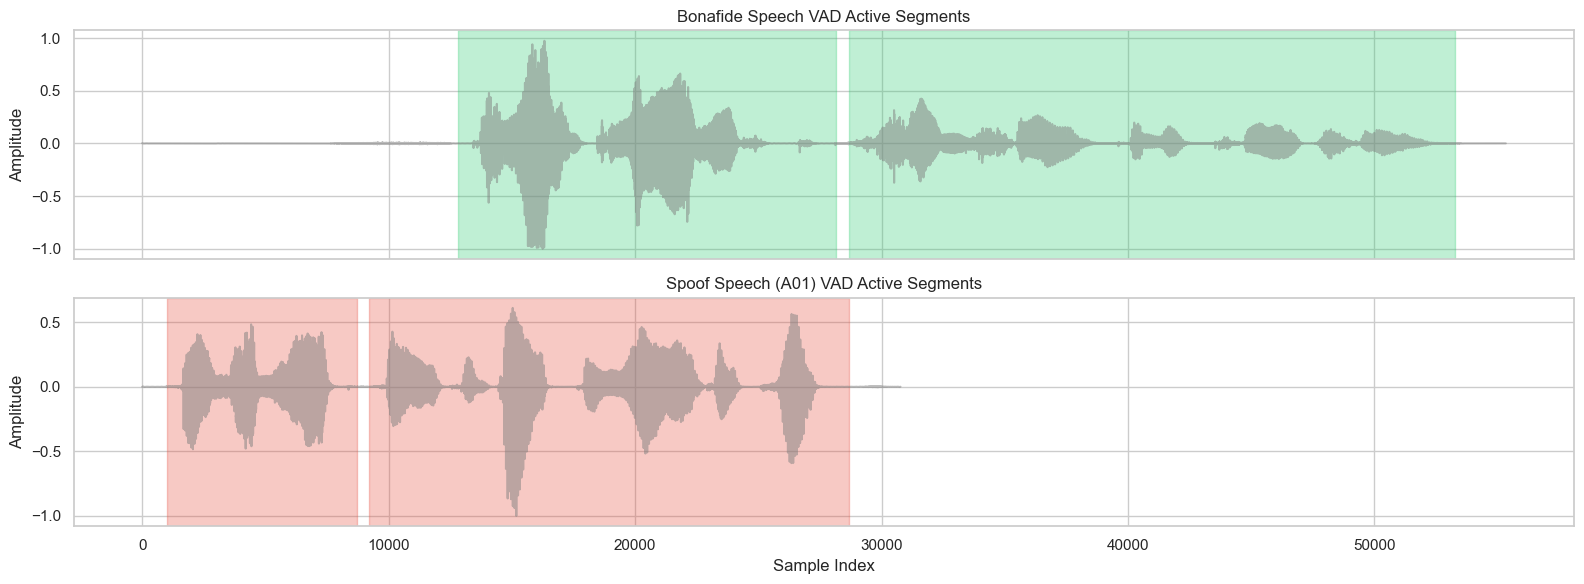

In [8]:
intervals_bon = librosa.effects.split(y=y_bon, top_db=35)
intervals_a01 = librosa.effects.split(y=y_a01, top_db=35)

fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
axes[0].plot(y_bon, color="gray", alpha=0.5)
for start, end in intervals_bon:
    axes[0].axvspan(start, end, color="#2ecc71", alpha=0.3)
axes[0].set_title("Bonafide Speech VAD Active Segments")
axes[0].set_ylabel("Amplitude")

axes[1].plot(y_a01, color="gray", alpha=0.5)
for start, end in intervals_a01:
    axes[1].axvspan(start, end, color="#e74c3c", alpha=0.3)
axes[1].set_title("Spoof Speech (A01) VAD Active Segments")
axes[1].set_ylabel("Amplitude")
axes[1].set_xlabel("Sample Index")
plt.tight_layout()
plt.show()